# Intro

This notebook plots the results generated by ```time_resolved_decoding.py``` code, which is the time resolved decoding results for all the sessions.

---
# Setup

In [10]:
##% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import seaborn as sns
import xarray as xr

from popy.decoding.decoder_plotting import show_population_decoder_results, show_single_session_decoder, show_prop_signif_units
from popy.decoding.decoder_tools import mask_N_consecutives
from popy.plotting.plot_cortical_grid import *
from popy.plotting.plotting_tools import plot_keypoints

from popy.config import PROJECT_PATH_LOCAL as PATH
from popy.config import COLORS

import os

# set fontsize to 8
plt.rcParams.update({'font.size': 8})

In [11]:
##% data tools
def remove_outliers_zscore(df, columns, threshold=5):
    z_scores = np.abs((df[columns] - df[columns].mean()) / df[columns].std())
    return df[(z_scores < threshold).all(axis=1)]

def load_decoding_res(monkey, folder='basics'):
    xr_res = xr.open_dataset(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', folder, f'{monkey}_decoding_results.nc'))
    xr_res.load()

    # remove nans along 'session' dimension
    #xr_res = xr_res.dropna('session')
    
    return xr_res

def load_decoding_res_new(folder='basics'):
    xr_res = xr.open_dataset(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', folder, 'scores.nc'))
    xr_res.load()

    if 'group_target' in xr_res.dims:
        if xr_res.group_target == 'None':
            xr_res = xr_res.mean('group_target')
        else:
            raise ValueError("group_target was used so the plotting method cant handle this.")


    # remove nans along 'session' dimension
    #xr_res = xr_res.dropna('session')
    
    return xr_res

def mask_N_consecutives(mask_xr, N=4):
    """
    Takes a mask (True/False) and sets to False any True value that is not part of N consecutive True values.
    
    Parameters
    ----------
    data : Xarray
        3D Xarray with dimensions (session, time, area)
    N : int
        Number of consecutive non-significant bins to mask
        
    Returns
    -------
    data_masked : Xarray
        3D Xarray with dimensions (session, time, area) with N consecutive non-significant bins masked.
    """

    # find where N consecutive values are False
    mask = np.empty(mask_xr.shape)
    for sess_id in range(mask_xr.shape[0]):
        for area_id in range(mask_xr.shape[2]):
            # get session data
            session_temp = mask_xr[sess_id, :, area_id].values

            consecutive_count = 0
            candidate_ids = []
            unit_signif_ids = []
            for i, if_signif_bin in enumerate(session_temp):
                # if not False, add to count
                if if_signif_bin:
                    consecutive_count += 1
                    candidate_ids.append(i)  # add to candidate indices (may or may not be part of N consecutive bins)
                    if consecutive_count >= N:
                        unit_signif_ids += candidate_ids  # add to list of significant indices
                        candidate_ids = []  # reset candidate ids
                else:  # reset
                    consecutive_count = 0
                    candidate_ids = []
            # create mask for this session (1 if significant, 0 if not) 
            unit_signif = np.zeros_like(session_temp)
            unit_signif[unit_signif_ids] = 1

            mask[sess_id, :, area_id] = unit_signif

    #data_masked = data.where(mask == 1)
    mask = mask.astype(bool)
    mask_xr.data = mask
    return mask_xr


In [12]:
##% plotting
def plot_identity(res_q_target, res_val_target, labels=None, title=None):
    # plot heatmap
    fig = plt.figure(figsize=(10, 10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 2], width_ratios=[2, 2])

    areas = ['LPFC', 'MCC']

    for i in range(2):
        matrix_q_temp = res_q_target.sel(area=areas[i])  # select area
        df_q_temp = matrix_q_temp.to_dataframe().reset_index()  # convert to dataframe
        matrix_val_temp = res_val_target.sel(area=areas[i])  # select area
        df_val_temp = matrix_val_temp.to_dataframe().reset_index()  # convert to dataframe

        # align dataframes (i.e. drop sessions that are not in both, and sort by session and time)
        df_temp = pd.merge(df_q_temp, df_val_temp, on=['session', 'time'], suffixes=('_q', '_val'))
        df_temp = df_temp.dropna(subset=['scores_q', 'scores_val'])
        # remove outliers (i.e. values that are too far from the mean)
        #df_temp = remove_outliers_zscore(df_temp, ['scores_q', 'scores_val'])
        df_temp = df_temp.loc[(df_temp['scores_q'] > 0) & (df_temp['scores_val'] > 0)]  # remove negative values

        # scatter plot 'score_q' vs 'score_val'
        X = df_temp[['scores_q', 'scores_val']].values

        # define identity line and fit line
        a, b = 1.0, 0.0  # slope, intercept
        a_, b_ = np.polyfit(X[:, 0], X[:, 1], 1)

        # projection on normal vector of identity line
        linepoint = np.array([0.0, b])
        normal_vector = np.array([a, -1.0])
        normal_vector /= np.linalg.norm(normal_vector)
        projection = np.dot(X - linepoint, normal_vector)  # projection on normal vector

        # scatter plot 'score_q' vs 'score_val'
        ax1 = plt.subplot(gs[i, 0])
        ax1.scatter(df_temp['scores_q'], df_temp['scores_val'], alpha=.2, color='black', s=1)
        # Plot the lines
        x_line = np.linspace(np.min([X[:, 0].min(), X[:, 1].min()]), np.max([X[:, 0].max(), X[:, 1].max()]), 10)
        y_line_identity = a * x_line + b
        y_line_fit = a_ * x_line + b_
        ax1.plot(x_line, y_line_identity, 'r-', label='Identity line')
        ax1.plot(x_line, y_line_fit, 'g-', label='Line of best fit')
    
        ax1.axhline(0, color='black', linewidth=.5)
        ax1.axvline(0, color='black', linewidth=.5)

        # x and y span are the same
        ax1.set_xlim([np.min([X[:, 0].min(), X[:, 1].min()]), np.max([X[:, 0].max(), X[:, 1].max()])])
        ax1.set_ylim([np.min([X[:, 0].min(), X[:, 1].min()]), np.max([X[:, 0].max(), X[:, 1].max()])])
        
        ax1.set_xlabel(f'{labels[0]} value coding (R2)')
        ax1.set_ylabel(f'{labels[1]} value coding (R2)')

        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(alpha=.5)
        ax1.set_title(areas[i])
        ax1.legend()

        # histogram of projection
        ax2 = plt.subplot(gs[i, 1])
        bins = np.linspace(-np.max(np.abs(projection)), np.max(np.abs(projection)), 11)
        ax2.hist(projection, bins=bins, alpha=.5, linewidth=1, edgecolor='black')
        ax2.axvline(0, color='red', linewidth=1, label='Identity line')
        ax2.set_xlabel(f'Distance from identity line\n<-- {labels[1]} better | {labels[0]} better -->')
        ax2.set_ylabel('Count')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(alpha=.5)
        ax2.set_title(areas[i])
        ax2.legend()

    if title is not None:
        plt.suptitle(title)

    plt.tight_layout()

    plt.show()

def plot_pop_coding(res, vmin=0, vmax=1, ax=None, n_extra_trials=(-1, 1), x_lim=None):

    areas = ['LPFC', 'MCC']
    subregions = ['MCC', 'dLPFC', 'vLPFC']

    # plot heatmap
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    for m, monkey in enumerate(np.unique(res.monkey.values)):
        # fill nan with -100
        n_sessions = len(res.sel(session=res.monkey == monkey).session)

        for i, subregion in enumerate(subregions):
            ax = axs[m, i]

            if subregion == 'MCC':
                res_temp = res.sel(area='MCC', session=res.monkey == monkey)
            else:
                res_temp = res.sel(area='LPFC', session=(res.lpfc_subregion == subregion) & (res.monkey == monkey))

            scores = res_temp.scores
            # pad along sessions dimension to have the same number of sessions
            if len(scores.session) < n_sessions:
                scores = scores.pad(session=(0, n_sessions - len(scores.session)), constant_values=np.nan)
            scores = scores.fillna(-100)
            im = ax.imshow(scores, origin='lower', aspect='auto', cmap='cividis',
                            extent=[res.time[0], res.time[-1], -.5, n_sessions-.5], 
                            vmin=vmin, vmax=vmax, interpolation=None)
            
            # add colorbar
            im = fig.colorbar(im, ax=ax, label='Decoding accuracy (R2 or %correct)')

            ax.set_xlabel('Time (s)')
            ax.set_ylabel('session & count significants')

            ax.set_yticks(np.arange(0, n_sessions, 1))
            sessions_subregion = [f'{num_sess} - {sess}' for num_sess, sess in enumerate(res_temp.session.values)]
            # pad with '' to have the same length of n_sessions
            if len(sessions_subregion) < n_sessions:
                sessions_subregion += [''] * (n_sessions - len(sessions_subregion))

            ax.set_yticklabels(sessions_subregion, fontsize=8)
            
            plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
            ax.grid(alpha=.5)

            ax.set_title(subregion)

            # plot num significant over time
            signifs = res_temp.if_significant 
            ax.plot(signifs.time, signifs.sum(dim='session'), color='red', label='n signif')
            ax.legend()

            if x_lim is not None:
                ax.set_xlim(x_lim)

            ax.title.set_text(f'{monkey} - {subregion}')

    plt.tight_layout()

    plt.show()

def plot_prop_signif_across(mask_target_ka_across, mask_target_ka_baseline, 
                            mask_target_po_across, mask_target_po_baseline, 
                            n_extra_trials=(-1, 1), x_lim=None, prop_lim=None):
    # plot heatmap
    w = 25  # cm
    h = 15  # cm
    fig, axs = plt.subplots(2, 2, figsize=(w/2.54, h/2.54), sharex=True)

    areas = ['LPFC', 'MCC']
    subregions = ['MCC', 'dLPFC', 'vLPFC']
    colors = ...
    #linestyle = {'across': '--', 'baseline': '-'}
    #linewidth = {'across': 1, 'baseline': 1}

    for m, monkey in enumerate(np.unique(res.monkey.values)):
        # fill nan with -100
        n_sessions = len(res.sel(session=res.monkey == monkey).session)

        for i, subregion in enumerate(subregions):
            ax = axs[m, i]

            if subregion == 'MCC':
                res_temp = res.sel(area='MCC', session=res.monkey == monkey)
            else:
                res_temp = res.sel(area='LPFC', session=(res.lpfc_subregion == subregion) & (res.monkey == monkey))

    for i, (mask_temp_across, mask_temp_baseline) in enumerate([(mask_target_ka_across, mask_target_ka_baseline),
                                                                (mask_target_po_across, mask_target_po_baseline)]):
        for j, area in enumerate(areas):
            ax = axs[i, j]
            # plot num significant over time
            data_baseline = np.mean(mask_temp_baseline.sel(area=area), axis=0)
            data_across = np.mean(mask_temp_across.sel(area=area), axis=0)

            data_baseline_smooth = np.convolve(data_baseline, np.ones(2)/2, mode='same')
            data_across_smooth = np.convolve(data_across, np.ones(2)/2, mode='same')

            ax.plot(data_baseline.time, data_baseline_smooth*100, color=colors[area], linestyle=linestyle['baseline'], label=f'baseline - {area}', linewidth=linewidth['baseline'], alpha=.7)
            ax.plot(data_across.time, data_across_smooth*100, color=colors[area], linestyle=linestyle['across'], label=f'across-target - {area}', linewidth=linewidth['across'], alpha=.7)

            title = f"Monkey: {['ka', 'po'][i]}, area: {area}"
            ax.set_title(title)

            # set y ticks at every.2
            ax.set_yticks(np.arange(0, 125, 25))  

            if prop_lim is not None:
                ax.set_ylim(prop_lim)
                
            # legend on the right
            ax.legend(loc='upper right')

            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Proportion of significant units')

            plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
            ax.grid(axis='x', alpha=.5)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            '''if title is not None:
                plt.suptitle(title)'''

            if x_lim is not None:
                ax.set_xlim(x_lim)
        
    #plt.tight_layout()

    return fig, ax

def plot_res_in_time(res, target, mode='prop_signifs', n_extra_trials=(-1, 1), x_lim=None, prop_lim=None, paper_format=False):
    if paper_format:
        # plot heatmap
        w = 3  # cm for paper: 3
        h = 2  # cm for paper: 2
    else:
        w = 20
        h = 7

    fig, axs = plt.subplots(1, 3, figsize=(w/2.54, h/2.54), sharex=True, sharey=True)

    fig.suptitle(f'Decoding {target}', fontsize=10)

    areas = ['LPFC', 'MCC']
    subregions = ['MCC', 'dLPFC', 'vLPFC']
    colors = COLORS
    linestyle = {'ka': '-', 'po': '--'}
    linewidth = {'ka': 1.5, 'po': 1}


    for i, subregion in enumerate(subregions):
        ax = axs[i]

        for m, monkey in enumerate(np.unique(res.monkey.values)):

            if subregion == 'MCC':
                res_temp = res.sel(area='MCC', session=res.monkey == monkey)
            else:
                res_temp = res.sel(area='LPFC', session=(res.lpfc_subregion == subregion) & (res.monkey == monkey))

            if mode == 'prop_signifs':
                # plot num significant over time
                data = res_temp.if_significant.mean('session') * 100
                data = np.convolve(data, np.ones(5)/5, mode='same')
                
            elif mode == 'mean_performance':
                # plot mean performance over time
                data = np.nanmean(res_temp.scores, axis=0)
                data = np.convolve(data, np.ones(5)/5, mode='same')

            else:
                raise ValueError("mode must be 'prop_signifs' or 'mean_performance'")

            ax.plot(res_temp.time, data, color=colors[subregion], linestyle=linestyle[monkey], label=f'{monkey} - {subregion}', alpha=.7)
            
            # legend on the right
            ax.legend(ncol=1, loc='upper right')

            ax.set_xlabel('Time (s)')
            if mode == 'prop_signifs':
                ax.set_ylabel('Percent significant sessions (%)')
            elif mode == 'mean_performance':
                ax.set_ylabel('Mean performance (R2 or %correct)')

            plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
            ax.grid(axis='x', alpha=.5)

            if mode=='mean_performance':
                #line at 0
                ax.axhline(0, color='k', linestyle='--', linewidth=1)


            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.set_title(subregion)

            if prop_lim is not None:
                # set y ticks at every.2
                #ax.set_yticks(np.linspace(prop_lim[0], prop_lim[1] + 0.01, 5))
                ax.set_ylim(prop_lim)
            
            if x_lim is not None:
                ax.set_xlim(x_lim)

        plt.tight_layout()

    return fig, ax




def plot_res_on_grid(res, mask, monkey, t_interest, vmin=None, vmax=None, title=None, bar_title=None):
    # plot on grid
    grid = init_location_grid()

    # set values of the mask to -100
    masked_res = res.where(mask, -100)

    locs_already_used = set()
    for session in res.session.values:
        for area in res.area.values:
            try:
                loc = get_grid_location(monkey, session, area)
                value = masked_res.sel(session=session, area=area).sel(time=t_interest, method='nearest').data
                
                if loc not in locs_already_used:
                    grid.loc[dict(x=loc[0], y=loc[1])] = value
                    locs_already_used.add(loc)
                else:  # use the best value
                    if value > grid.loc[dict(x=loc[0], y=loc[1])]:
                        grid.loc[dict(x=loc[0], y=loc[1])] = value


            except Exception as e:
                print(e)

    plot_matrix(grid, monkey, vmin=vmin, vmax=vmax, title=title, label=bar_title, not_signif_value=-100)


def add_subareas(res):
    metadata = load_metadata()

    subregions = []
    for sess_temp in res.session.values:
        res_temp = res.sel(session=sess_temp)
        # get session metadata
        monkey, session = res_temp.monkey, sess_temp.split('_')[1]
        lpfc_subregion = metadata.loc[(metadata['monkey'] == monkey) & (metadata['session'] == session), 'LPFC_subregion'].values[0]
        subregions.append(lpfc_subregion)

    # add new coordinate along (session, area) dimension
    res = res.assign_coords(lpfc_subregion=('session', subregions))

    return res


def plot_analysis(target,
                  plim, 
                  vmin, vmax, 
                  n_extra_trials, 
                  N_consecutives=4,
                  x_lim=None,
                  prop_lim=None,
                  bar_title=None, 
                  folder=None):
    
    # Processing results

    res = load_decoding_res_new(folder=folder)
    res = add_subareas(res)  # add subareas to the results 
    res = res.sel(target=target)  # select target of interest, e.g. feedback or value

    # if 'group' in dims and its nan, remove it. if not nan, raise error
    if 'group_target' in res.dims:
        if res.group_target == 'None':
            res = res.mean('group_target')
        else:
            raise ValueError("group_target was used so the plotting method cant handle this.")
        
    # mask significants
    res_target_signifs = mask_N_consecutives(res.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
    res['if_significant'] = res_target_signifs  # add as new dataarray to the results

    # Plotting

    # plot whole population
    plot_pop_coding(res, vmin=vmin, vmax=vmax, n_extra_trials=n_extra_trials, x_lim=x_lim)

    # plot proportion of significant sessions
    plot_res_in_time(res, target, mode='prop_signifs', n_extra_trials=n_extra_trials, x_lim=x_lim, prop_lim=prop_lim, paper_format=False)
    plot_res_in_time(res, target, mode='mean_performance', n_extra_trials=n_extra_trials, x_lim=x_lim, paper_format=False, prop_lim=[vmin, vmax])


    # plot best sessions on grid
    #plot_res_on_grid(res_target_ka, mask_target_ka, 'ka', t_interest=t_interest, vmin=vmin, vmax=vmax, title=f'{target}\nmonkey: ka, time: {t_interest}s', bar_title=bar_title)
    #plot_res_on_grid(res_target_po, mask_target_po, 'po', t_interest=t_interest, vmin=vmin, vmax=vmax, title=f'{target}\nmonkey: po, time: {t_interest}s', bar_title=bar_title)


---
# 1. Decoding Strategy value

## 1.4 Shift value multiple alphas

In [13]:
def add_if_signif(res, plim=.05, N_consecutives=4):
    res_teagrets = []
    for j, target in enumerate(res.target.values):
        # mask significants, convert to 0 or 1 instead of p values
        res_temp = res.sel(target=target)
        res_temp_signifs = mask_N_consecutives(res_temp.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
        res_temp['if_significant'] = res_temp_signifs  # add as new dataarray to the results

        res_teagrets.append(res_temp)

    res = xr.concat(res_teagrets, dim='target')
    return res  

def remove_irrelevant_sessions(res):
    sessions_good = []
    for session in res.session.data:
        for area in res.area.data:
            res_temp = res.sel(session=session, area=area)

            if np.any(res_temp.if_significant.sel(time=slice(2, 3.5)).sum('time') > 0) and np.any(res_temp.scores.sel(time=slice(2, 3.5)).sum('time') > 0.1):
                sessions_good.append((session, area))
            else:
                res.loc[dict(session=session, area=area)] = np.nan
                
    print(f'kept: {len(sessions_good)} / {len(res.session.data)*len(res.area.data)}')
    return res



In [14]:
res_alphas_original = load_decoding_res_new(folder='multiple_alphas_ridge')
res_alphas_original = add_if_signif(res_alphas_original, plim=.05, N_consecutives=4)
res_alphas_original = remove_irrelevant_sessions(res_alphas_original)  # remove sessions that are not significant enough
res_alphas_original = add_subareas(res_alphas_original)  # add subareas to the results
res_alphas_original

kept: 66 / 230


<xarray.Dataset>
Dimensions:         (target: 19, session: 115, time: 75, area: 2)
Coordinates:
  * target          (target) <U15 'stay_value_0.05' ... 'stay_value_0.95'
  * area            (area) object 'LPFC' 'MCC'
  * time            (time) float64 0.0 0.1 0.2 0.3 0.4 ... 7.0 7.1 7.2 7.3 7.4
  * session         (session) object 'ka_230520' 'ka_090720' ... 'po_200722'
    monkey          (session) object 'ka' 'ka' 'ka' 'ka' ... 'po' 'po' 'po' 'po'
    lpfc_subregion  (session) <U5 'dLPFC' 'dLPFC' 'dLPFC' ... 'dLPFC' 'dLPFC'
Data variables:
    scores          (target, session, time, area) float64 nan nan ... -0.05522
    pvals           (target, session, time, area) float64 nan nan ... nan 0.1238
    perm_mean       (target, session, time, area) float64 nan nan ... -0.09404
    perm_std        (target, session, time, area) float64 nan nan ... 0.03253
    if_significant  (target, session, time, area) bool True True ... True False

In [15]:
"""cut_percentile = .1  # we remove extreme outliers to get interpretable results
eval_window = [2, 3.5]  # this is the time window under which we average the decoder performances for the second plot

x_lim=(1, 5)  # time window to show

paper_format = False
show_datapoints = True  # whether to show individual data points or not

monkeys = np.unique(res_alphas_original.monkey.values)
areas = ['MCC', 'dLPFC', 'vLPFC']
targets = res_alphas_original.target.values
alphas = [float(target.split("_")[-1]) for target in targets]

# color gradient red to green
colors = plt.cm.coolwarm(np.linspace(0, 1, len(targets)))
from popy.config import MODEL_PARAMS
alpha_monkey = {'ka': MODEL_PARAMS['ka']['alpha'], 'po': MODEL_PARAMS['po']['alpha']}

# plot size in cm
if paper_format:
    w = 6
    h = 4
else:
    w = 20
    h = 15
    

for m, monkey_temp in enumerate(monkeys):
    for a, area_temp in enumerate(areas):
        
        fig, axs = plt.subplots(2, 3, figsize=(w/2.54, (h/2)/2.54), sharex='col')

        # set padding to 0
        plt.subplots_adjust(wspace=0, hspace=0)
        title = f'Monkey: {monkey_temp}, area: {area_temp}'
        fig.suptitle(title)
        
        for i, target_temp in enumerate(targets):
            if i == 0 or i == len(targets)-1:
                continue
            
            res_alphas_temp = res_alphas_original.sel(target=target_temp, session=res_alphas_original.monkey == monkey_temp)

            scores_temp = res_alphas_temp.scores
            scores_temp = scores_temp.where(scores_temp > scores_temp.quantile(cut_percentile), np.nan)  # remove outliers
            
            if area_temp == 'MCC':
                scores_in_time = scores_temp.sel(area=area_temp).mean('session')
                scores_at_time = scores_temp.sel(area=area_temp, time=slice(*eval_window)).mean('time')
            else:
                scores_in_time = scores_temp.sel(area='LPFC', session=scores_temp.lpfc_subregion == area_temp).mean('session')
                scores_at_time = scores_temp.sel(area='LPFC', session=scores_temp.lpfc_subregion == area_temp, time=slice(*eval_window)).mean('time')

            # plot every 4th trajectorie for clarity
            #if (i-1) % 4 == 0:                
            # plot mean r2 over time
            ax = axs[0]
            scores_in_time_smooth = np.convolve(scores_in_time, np.ones(5)/5, mode='same')
            ax.plot(res_alphas_temp.time, scores_in_time_smooth, color=colors[i], linewidth=1.5, alpha=.7)

            # plot mean r2 at time
            ax = axs[1]  
            '''sns.boxplot(
                x=alphas[i],
                y=scores_at_time,
                color=colors[i],
                ax=ax,
                showfliers=False  # show outliers (default is True, but set explicitly)
            )'''

            # Plot individual data points with actual x-values

            ax.scatter(
                alphas[i],
                scores_at_time.mean(),
                color=colors[i],
                s=40,  # size
                alpha=1,
                zorder=10
            )

            # Add jitter to x-coordinates for better visualization
            if show_datapoints:
                x_jittered = alphas[i] + np.random.normal(0, 0.005, len(scores_at_time))
                
                ax.scatter(
                    x_jittered,
                    scores_at_time,
                    color='black',
                    s=10,  # size
                    alpha=0.5
                )

            ax.axvline(alpha_monkey[monkey_temp], color='tab:red', linestyle='--', alpha=.5)

        # set plot properties
        for i in range(2):
            plot_keypoints(axs[0], n_extra_trials=(0, 0), fontsize=8, rotation=90)
            axs[0].grid(axis='x', alpha=.5)
            axs[0].set_xlim(x_lim)
            # reset ylim
            ylim = axs[0].get_ylim()
            axs[0].set_ylim(ylim)
            #axs[i, 1].legend()
            axs[1].set_xlabel('Alpha')
            axs[0].set_xlabel('Time (s)')

            for j in range(2):
                if i == 0:
                    axs[j].set_ylabel('% signif sessions')
                else:
                    axs[j].set_ylabel('Mean R2')

                axs[j].spines['top'].set_visible(False)
                axs[j].spines['right'].set_visible(False)

        #plt.tight_layout()

        #floc = os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', f'multiple_alphas_{monkey_temp}_{area_temp}.svg')
        #fig.savefig(floc, bbox_inches='tight', dpi=300, transparent=True)"""

'cut_percentile = .1  # we remove extreme outliers to get interpretable results\neval_window = [2, 3.5]  # this is the time window under which we average the decoder performances for the second plot\n\nx_lim=(1, 5)  # time window to show\n\npaper_format = False\nshow_datapoints = True  # whether to show individual data points or not\n\nmonkeys = np.unique(res_alphas_original.monkey.values)\nareas = [\'MCC\', \'dLPFC\', \'vLPFC\']\ntargets = res_alphas_original.target.values\nalphas = [float(target.split("_")[-1]) for target in targets]\n\n# color gradient red to green\ncolors = plt.cm.coolwarm(np.linspace(0, 1, len(targets)))\nfrom popy.config import MODEL_PARAMS\nalpha_monkey = {\'ka\': MODEL_PARAMS[\'ka\'][\'alpha\'], \'po\': MODEL_PARAMS[\'po\'][\'alpha\']}\n\n# plot size in cm\nif paper_format:\n    w = 6\n    h = 4\nelse:\n    w = 20\n    h = 15\n    \n\nfor m, monkey_temp in enumerate(monkeys):\n    for a, area_temp in enumerate(areas):\n        \n        fig, axs = plt.subplots(

ka - MCC: 22 / 62 sessions (40 NaN)
ka - dLPFC: 3 / 49 sessions (46 NaN)
ka - vLPFC: 7 / 12 sessions (5 NaN)
po - MCC: 25 / 53 sessions (28 NaN)
po - dLPFC: 5 / 45 sessions (40 NaN)
po - vLPFC: 3 / 7 sessions (4 NaN)


/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_70966/2722477556.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


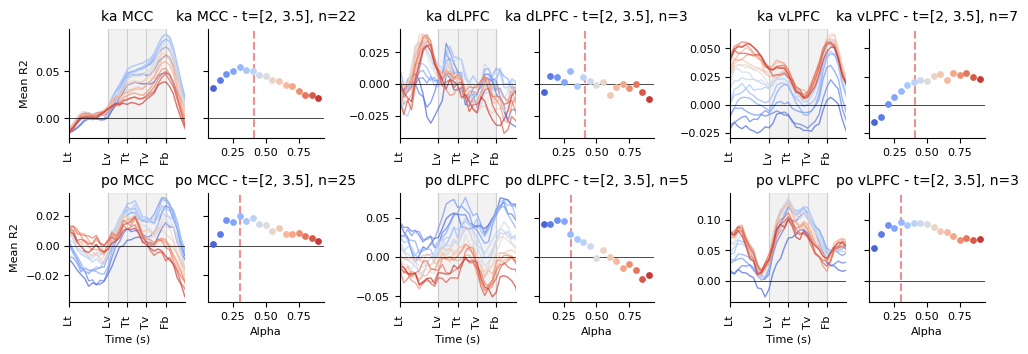

In [24]:
import matplotlib.gridspec as gridspec

cut_percentile = 0.01  # we remove extreme outliers to get interpretable results
eval_window = [2, 3.5]  # this is the time window under which we average the decoder performances for the second plot

x_lim=(1, 4)  # time window to show

paper_format = True
show_datapoints = False  # whether to show individual data points or not

monkeys = np.unique(res_alphas_original.monkey.values)
areas = ['MCC', 'dLPFC', 'vLPFC']
targets = res_alphas_original.target.values
alphas = [float(target.split("_")[-1]) for target in targets]

# color gradient red to green
colors = plt.cm.coolwarm(np.linspace(0, 1, len(targets)))
from popy.config import MODEL_PARAMS
alpha_monkey = {'ka': MODEL_PARAMS['ka']['alpha'], 'po': MODEL_PARAMS['po']['alpha']}

# plot size in cm
if paper_format:
    w = 30
    h = 9
    s = 15
    lw = 1
else:
    w = 36
    h = 18
    s = 40
    lw = 1.5

# Create figure
fig = plt.figure(figsize=(w/2.54, h/2.54))

# Create a master grid: 2 rows (monkeys) × 3 columns (areas)
outer_grid = gridspec.GridSpec(2, 3, figure=fig, hspace=.5, wspace=0.3)

# Iterate through each monkey-area combination
for m, monkey_temp in enumerate(monkeys):
    for a, area_temp in enumerate(areas):
        
        # Create inner grid for this (monkey, area) pair: 1 row × 2 columns with NO gap
        inner_grid = gridspec.GridSpecFromSubplotSpec(1, 2, outer_grid[m, a], 
                                                     wspace=0.2, hspace=0)
        
        # Create subplots - time series first, then alpha with shared y-axis
        ax_time = fig.add_subplot(inner_grid[0, 0])   # Time series subplot
        ax_alpha = fig.add_subplot(inner_grid[0, 1], sharey=ax_time)  # Alpha subplot with shared y
        ax_alpha.tick_params(labelleft=False)

        for i, target_temp in enumerate(targets):
            if i == 0 or i == len(targets)-1:
                continue
            
            res_alphas_temp = res_alphas_original.sel(target=target_temp, session=res_alphas_original.monkey == monkey_temp)

            scores_temp = res_alphas_temp.scores
            scores_temp = scores_temp.where(scores_temp > scores_temp.quantile(cut_percentile), np.nan)  # remove outliers
            
            if area_temp == 'MCC':
                scores_all = scores_temp.sel(area=area_temp)
                scores_in_time = scores_all.mean('session')
                scores_at_time = scores_all.sel(time=slice(*eval_window)).mean('time')      
            else:
                scores_all = scores_temp.sel(area='LPFC', session=scores_temp.lpfc_subregion == area_temp)
                scores_in_time = scores_all.mean('session')
                scores_at_time = scores_all.sel(time=slice(*eval_window)).mean('time')

            # Plot time series
            scores_in_time_smooth = np.convolve(scores_in_time, np.ones(5)/5, mode='same')
            ax_time.plot(res_alphas_temp.time, scores_in_time_smooth, color=colors[i], alpha=.7, linewidth=lw)

            # Plot alpha scatter
            ax_alpha.scatter(
                alphas[i],
                scores_at_time.mean(),
                color=colors[i],
                s=s,
                alpha=1,
                zorder=10
            )

            # Add individual data points with jitter
            if show_datapoints:
                x_jittered = alphas[i] + np.random.normal(0, 0.005, len(scores_at_time))
                ax_alpha.scatter(
                    x_jittered,
                    scores_at_time,
                    color='black',
                    s=s/5,
                    alpha=0.5
                )

        # add grey shadow in the background for the time of interest
        ax_time.axvspan(eval_window[0], eval_window[1], color='grey', alpha=0.1, label='Eval Window')

        n_sessions = len(scores_all)
        n_sessions_nonnan = np.count_nonzero(~np.isnan((scores_all.mean('time'))))
        n_sessions_nan = np.count_nonzero(np.isnan((scores_all.mean('time'))))
        print(f'{monkey_temp} - {area_temp}: {n_sessions_nonnan} / {n_sessions} sessions ({n_sessions_nan} NaN)')
         
        # Set titles only on top row
        ax_time.set_title(f'{monkey_temp} {area_temp}', fontsize=10)
        ax_alpha.set_title(f'{monkey_temp} {area_temp} - t={eval_window}, n={n_sessions_nonnan}', fontsize=10)

        # Add vertical line for monkey-specific alpha
        ax_alpha.axvline(alpha_monkey[monkey_temp], color='tab:red', linestyle='--', alpha=.5)

        # Set properties for time series plot
        plot_keypoints(ax_time, n_extra_trials=(0, 0), fontsize=8, xlabels='short')
        ax_time.grid(axis='x', alpha=.5)
        ax_time.set_xlim(x_lim)
        
        # Manually adjust y-axis limits based on visible data within x_lim
        y_values = []
        for line in ax_time.get_lines():
            x_data = line.get_xdata()
            y_data = line.get_ydata()
            # Find y values within the x_lim range
            mask = (x_data >= x_lim[0]) & (x_data <= x_lim[1])
            if np.any(mask):
                y_values.extend(y_data[mask])
        
        if y_values:
            y_min, y_max = np.nanmin(y_values), np.nanmax(y_values)
            y_range = y_max - y_min
            margin = y_range * 0.05  # Add 5% margin
            ax_time.set_ylim(y_min - margin, y_max + margin)
        
        # Set x-labels only on bottom row
        if m == len(monkeys) - 1:
            ax_time.set_xlabel('Time (s)')
            ax_alpha.set_xlabel('Alpha')
        
        # Set y-labels only on leftmost subplots
        if a == 0:
            ax_time.set_ylabel('Mean R2')
        else:
            # Remove y-axis labels and ticks for non-leftmost time plots
            #ax_time.set_ylabel('')
            #ax_time.tick_params(left=False, labelleft=False)
            ...
        
        # Remove spines
        ax_time.spines['top'].set_visible(False)
        ax_time.spines['right'].set_visible(False)
        ax_alpha.spines['top'].set_visible(False)
        ax_alpha.spines['right'].set_visible(False)
        

        ax_alpha.axhline(0, color='black', linewidth=.5)
        ax_time.axhline(0, color='black', linewidth=.5)

if paper_format:
    plt.tight_layout()

plt.show()